# Bibliotekos

Užkraunamos reikalingos bibliotekos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from pingouin import partial_corr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')

# Duomenų paruošimas

Įkeliami ir sutvarkomi duomenys.

In [2]:
churn_data = pd.read_csv('../datasets/Customer Churn.csv')

churn_data = churn_data.rename(columns={
    'Call  Failure':          'call_failure',
    'Complains':              'complains',
    'Subscription  Length':   'subscription_length',
    'Charge  Amount':         'charge_amount',
    'Seconds of Use':         'sec_of_use',
    'Frequency of use':       'freq_of_use',
    'Frequency of SMS':       'freq_of_SMS',
    'Distinct Called Numbers':'distinct_called_numbers',
    'Age Group':              'age_group',
    'Tariff Plan':            'tariff_plan',
    'Status':                 'status',
    'Age':                    'age',
    'Customer Value':         'customer_value',
    'Churn':                  'churn'
})

factor_cols = ['complains', 'charge_amount', 'age_group', 'tariff_plan', 'status', 'churn']
for col in factor_cols:
    churn_data[col] = churn_data[col].astype('category')

churn_data.head()

,call_failure,complains,subscription_length,charge_amount,sec_of_use,freq_of_use,freq_of_SMS,distinct_called_numbers,age_group,tariff_plan,status,age,customer_value,churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


# Pradinė analizė
## Praleistos reikšmės

In [3]:
print('Iš viso praleistų reikšmių:', churn_data.isna().sum().sum())

Iš viso praleistų reikšmių: 0


## Išskirtys

In [4]:
def count_outliers(data, var_name):
    col = data[var_name].dropna()
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    H  = Q3 - Q1
    inner_low   = Q1 - 1.5 * H
    inner_high  = Q3 + 1.5 * H
    outer_low   = Q1 - 3.0 * H
    outer_high  = Q3 + 3.0 * H
    mild    = int(((col < inner_low)  & (col > outer_low)  |
                   (col > inner_high) & (col < outer_high)).sum())
    extreme = int(((col < outer_low)  | (col > outer_high)).sum())
    return {
        'variable':         var_name,
        'Q1':               round(Q1, 4),
        'Q3':               round(Q3, 4),
        'H':                round(H,  4),
        'inner_low':        round(inner_low,  4),
        'inner_high':       round(inner_high, 4),
        'outer_low':        round(outer_low,  4),
        'outer_high':       round(outer_high, 4),
        'mild_outliers':    mild,
        'extreme_outliers': extreme
    }

In [5]:
numeric_cols    = churn_data.select_dtypes(include='number').columns.tolist()
outlier_summary = pd.DataFrame([count_outliers(churn_data, c) for c in numeric_cols])
outlier_summary

,variable,Q1,Q3,H,inner_low,inner_high,outer_low,outer_high,mild_outliers,extreme_outliers
0,call_failure,1.0000,12.0000,11.0000,-15.50,28.50,-32.0000,45.0000,47,0
1,subscription_length,30.0000,38.0000,8.0000,18.00,50.00,6.0000,62.0000,256,18
2,sec_of_use,1391.2500,6478.2500,5087.0000,-6239.25,14108.75,-13869.7500,21739.2500,200,0
3,freq_of_use,27.0000,95.0000,68.0000,-75.00,197.00,-177.0000,299.0000,129,0
4,freq_of_SMS,6.0000,87.0000,81.0000,-115.50,208.50,-237.0000,330.0000,182,186
5,distinct_called_numbers,10.0000,34.0000,24.0000,-26.00,70.00,-62.0000,106.0000,77,0
6,age,25.0000,30.0000,5.0000,17.50,37.50,10.0000,45.0000,123,170
7,customer_value,113.8012,788.3888,674.5875,-898.08,1800.27,-1909.9613,2812.1513,116,0


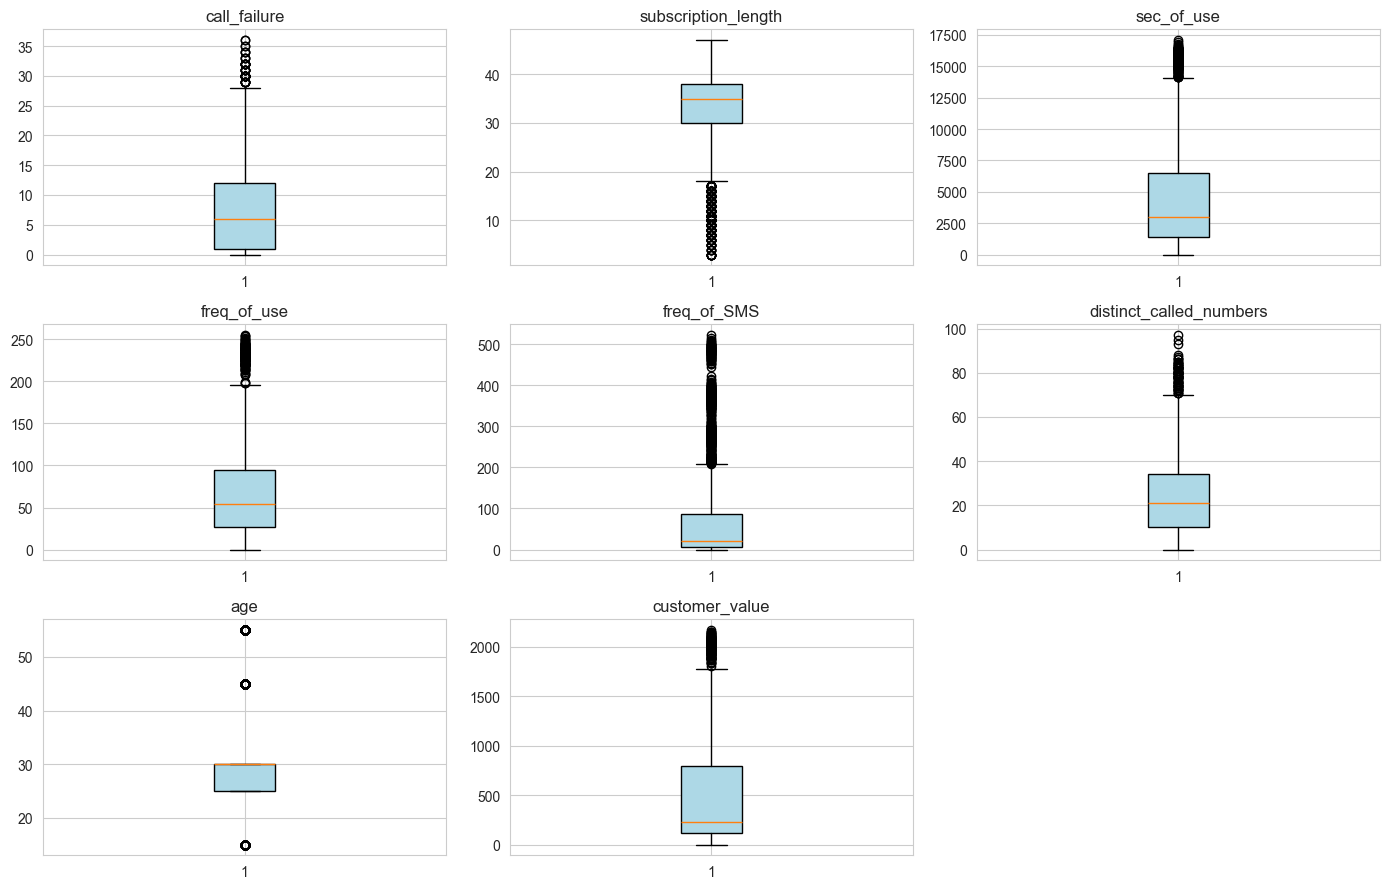

In [6]:
numeric_data = churn_data.select_dtypes(include='number')
n_cols = len(numeric_data.columns)
ncols  = 3
nrows  = (n_cols + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_data.columns):
    axes[i].boxplot(numeric_data[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Skaitinės charakteristikos

In [7]:
num_cols = churn_data.select_dtypes(include='number').columns.tolist()

def compute_stats(group):
    rows = []
    for col in num_cols:
        v = group[col].dropna()
        rows.append({
            'Variable': col,
            'min':    round(v.min(),          4),
            'max':    round(v.max(),          4),
            'mean':   round(v.mean(),         4),
            'sd':     round(v.std(),          4),
            'q25':    round(v.quantile(0.25), 4),
            'median': round(v.median(),       4),
            'q75':    round(v.quantile(0.75), 4),
        })
    return pd.DataFrame(rows)

char = (
    churn_data
    .groupby('churn', observed=True)
    .apply(compute_stats)
    .reset_index(level=0)
    .reset_index(drop=True)
)
char

,churn,Variable,min,max,mean,sd,q25,median,q75
0,0,call_failure,0.0,36.000,7.6561,7.1543,1.000,6.00,12.0000
1,0,subscription_length,3.0,47.000,32.6625,8.3924,29.000,35.00,38.0000
2,0,sec_of_use,0.0,17090.000,5014.2241,4312.7426,1819.000,3530.00,6892.5000
3,0,freq_of_use,0.0,255.000,76.9793,58.4998,32.000,63.00,104.0000
4,0,freq_of_SMS,0.0,522.000,83.8716,118.8086,7.000,25.00,133.0000
5,0,distinct_called_numbers,0.0,97.000,25.5827,17.3893,12.000,23.00,36.0000
6,0,age,15.0,55.000,31.0659,9.1476,25.000,30.00,30.0000
7,0,customer_value,0.0,2165.280,535.5115,536.2146,142.065,268.07,864.5475
8,1,call_failure,0.0,34.000,7.4768,7.8314,0.000,5.00,11.0000
9,1,subscription_length,3.0,45.000,31.8949,9.4692,31.000,35.00,37.0000


## Atsakas

In [8]:
print(churn_data['churn'].value_counts().sort_index())

churn
0    2655
1     495
Name: count, dtype: int64


## Kiekybinių kintamųjų analizė

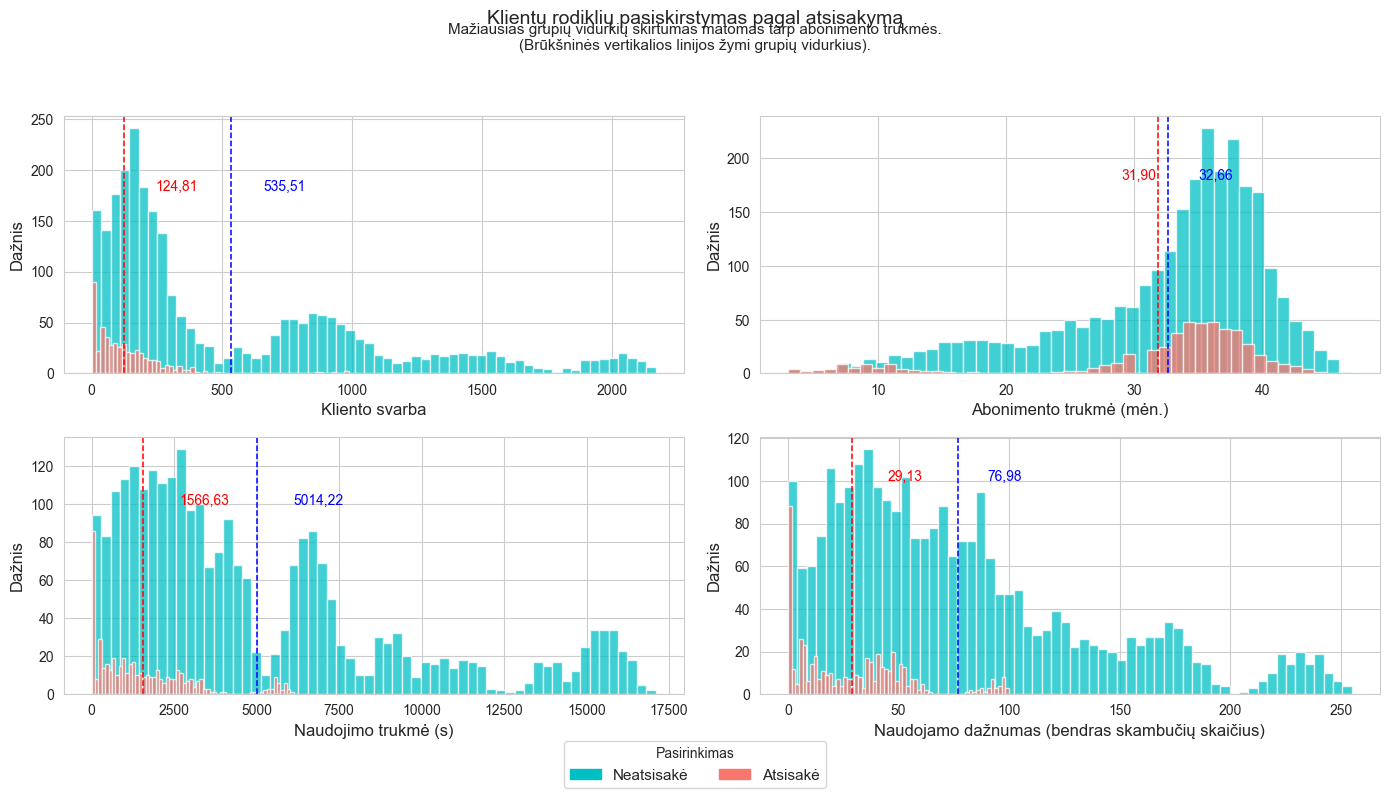

In [9]:
COLOR = {'0': '#00BFC4', '1': '#F8766D'}

def hist_by_churn(ax, col, x_label, bins, vlines):
    for val, color in COLOR.items():
        subset = churn_data[churn_data['churn'].astype(str) == val][col]
        label  = 'Neatsisakė' if val == '0' else 'Atsisakė'
        ax.hist(subset, bins=bins, alpha=0.75, color=color, label=label)
    for xint, color, text, tx, ty in vlines:
        ax.axvline(xint, color=color, linewidth=1.1, linestyle='--')
        ax.text(tx, ty, text, color=color, fontsize=10)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel('Dažnis', fontsize=12)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

hist_by_churn(axes[0,0], 'customer_value', 'Kliento svarba', 60,
    [(535.5115, 'blue', '535,51', 660, 180),
     (124.8114, 'red',  '124,81', 245, 180)])

hist_by_churn(axes[0,1], 'subscription_length', 'Abonimento trukmė (mėn.)', 45,
    [(32.6625, 'blue', '32,66', 35, 180),
     (31.8949, 'red',  '31,90', 29, 180)])

hist_by_churn(axes[1,0], 'sec_of_use', 'Naudojimo trukmė (s)', 60,
    [(5014.2241, 'blue', '5014,22', 6100, 100),
     (1566.6323, 'red',  '1566,63', 2650, 100)])

hist_by_churn(axes[1,1], 'freq_of_use', 'Naudojamo dažnumas (bendras skambučių skaičius)', 60,
    [(76.9793, 'blue', '76,98', 90, 100),
     (29.1333, 'red',  '29,13', 45, 100)])

handles = [mpatches.Patch(color='#00BFC4', label='Neatsisakė'),
           mpatches.Patch(color='#F8766D', label='Atsisakė')]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=11, title='Pasirinkimas')
fig.suptitle('Klientų rodiklių pasiskirstymas pagal atsisakymą', fontsize=14)
fig.text(0.5, 0.93,
    'Mažiausias grupių vidurkių skirtumas matomas tarp abonimento trukmės.\n'
    '(Brūkšninės vertikalios linijos žymi grupių vidurkius).',
    ha='center', fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 0.91])
plt.show()

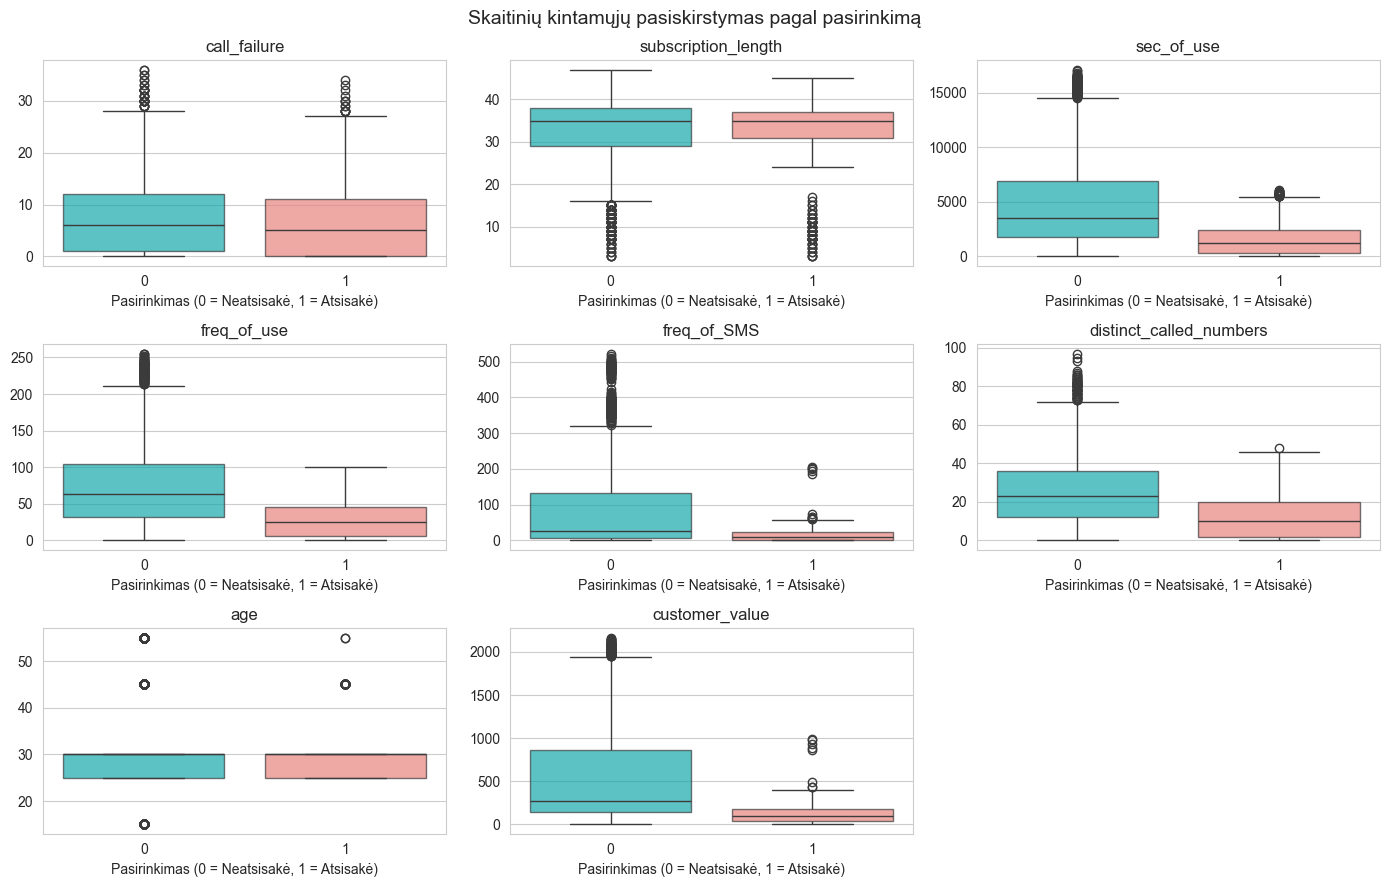

In [ ]:
num_cols_plot = churn_data.select_dtypes(include='number').columns.tolist()
n     = len(num_cols_plot)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    sns.boxplot(data=churn_data, x='churn', y=col, palette=COLOR, ax=axes[i])
    for patch in axes[i].patches:
        patch.set_alpha(0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('Pasirinkimas (0 = Neatsisakė, 1 = Atsisakė)')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Skaitinių kintamųjų pasiskirstymas pagal pasirinkimą', fontsize=14)
plt.tight_layout()
plt.show()

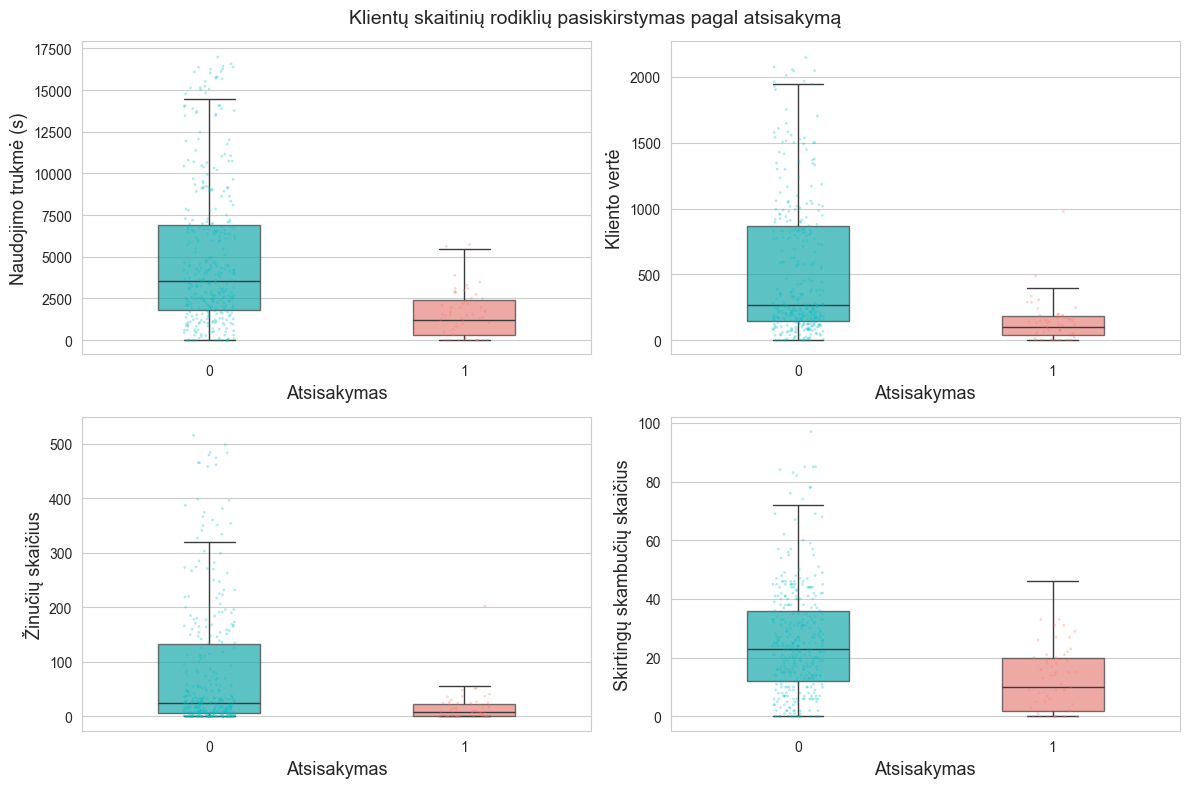

In [ ]:
vars4 = [
    ('sec_of_use',              'Naudojimo trukmė (s)'),
    ('customer_value',          'Kliento vertė'),
    ('freq_of_SMS',             'Žinučių skaičius'),
    ('distinct_called_numbers', 'Skirtingų skambučių skaičius'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (col, ylabel) in enumerate(vars4):
    sns.boxplot(data=churn_data, x='churn', y=col,
                palette=COLOR, width=0.4, fliersize=0, ax=axes[i])
    for patch in axes[i].patches:
        patch.set_alpha(0.7)
    sns.stripplot(data=churn_data.sample(min(400, len(churn_data)), random_state=1),
                  x='churn', y=col, palette=COLOR,
                  alpha=0.3, size=2, jitter=True, ax=axes[i])
    axes[i].set_xlabel('Atsisakymas', fontsize=13)
    axes[i].set_ylabel(ylabel, fontsize=13)

fig.suptitle('Klientų skaitinių rodiklių pasiskirstymas pagal atsisakymą', fontsize=14)
plt.tight_layout()
plt.show()

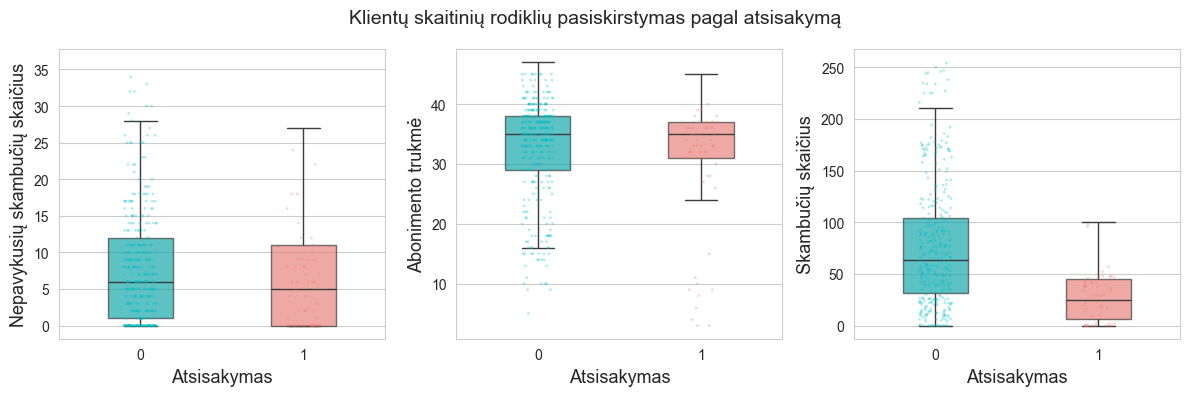

In [ ]:
vars3 = [
    ('call_failure',        'Nepavykusių skambučių skaičius'),
    ('subscription_length', 'Abonimento trukmė'),
    ('freq_of_use',         'Skambučių skaičius'),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, (col, ylabel) in enumerate(vars3):
    sns.boxplot(data=churn_data, x='churn', y=col,
                palette=COLOR, width=0.4, fliersize=0, ax=axes[i])
    for patch in axes[i].patches:
        patch.set_alpha(0.7)
    sns.stripplot(data=churn_data.sample(min(400, len(churn_data)), random_state=1),
                  x='churn', y=col, palette=COLOR,
                  alpha=0.3, size=2, jitter=True, ax=axes[i])
    axes[i].set_xlabel('Atsisakymas', fontsize=13)
    axes[i].set_ylabel(ylabel, fontsize=13)

fig.suptitle('Klientų skaitinių rodiklių pasiskirstymas pagal atsisakymą', fontsize=14)
plt.tight_layout()
plt.show()

## Kokybinių kintamųjų analizė

In [13]:
cat_cols = [c for c in churn_data.columns
            if churn_data[c].dtype.name == 'category' and c != 'churn']

for col in cat_cols:
    print(f'\n--- Kryžminė lentelė kintamajam: {col} ---')
    print(pd.crosstab(churn_data[col], churn_data['churn'],
                      rownames=[col], colnames=['Churn']))


--- Kryžminė lentelė kintamajam: complains ---
Churn         0    1
complains           
0          2614  295
1            41  200

--- Kryžminė lentelė kintamajam: charge_amount ---
Churn             0    1
charge_amount           
0              1347  421
1               574   43
2               372   23
3               192    7
4                75    1
5                30    0
6                11    0
7                14    0
8                19    0
9                14    0
10                7    0

--- Kryžminė lentelė kintamajam: age_group ---
Churn         0    1
age_group           
1           123    0
2           853  184
3          1195  230
4           316   79
5           168    2

--- Kryžminė lentelė kintamajam: tariff_plan ---
Churn           0    1
tariff_plan           
1            2416  489
2             239    6

--- Kryžminė lentelė kintamajam: status ---
Churn      0    1
status           
1       2243  125
2        412  370


## Koreliacijos

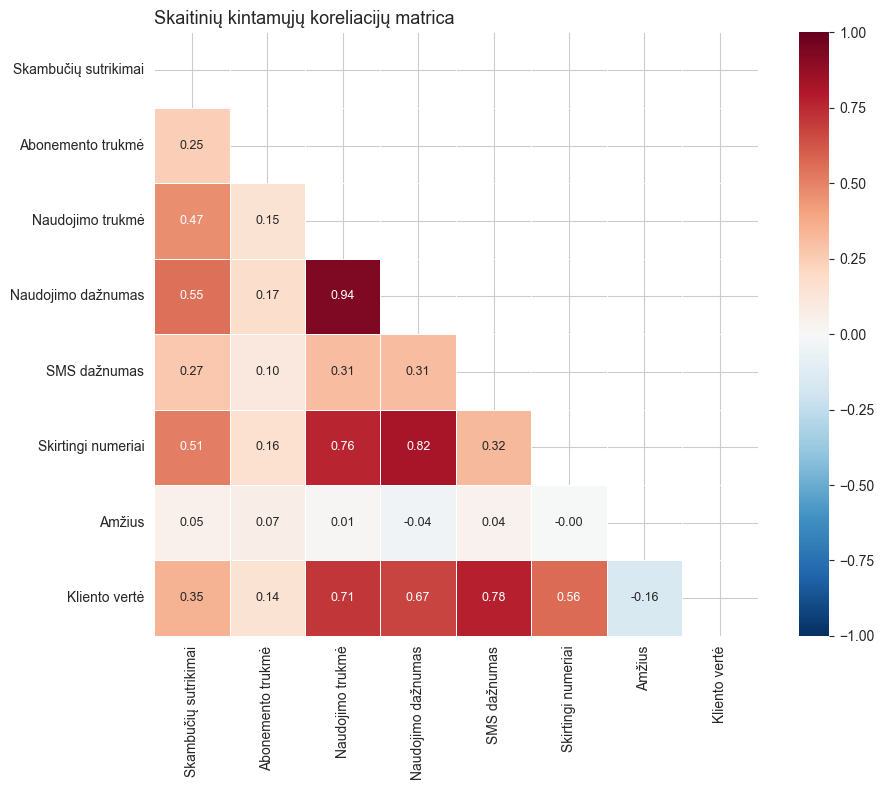

In [14]:
numeric_values = churn_data.select_dtypes(include='number').rename(columns={
    'call_failure':            'Skambučių sutrikimai',
    'subscription_length':     'Abonemento trukmė',
    'sec_of_use':              'Naudojimo trukmė',
    'freq_of_use':             'Naudojimo dažnumas',
    'freq_of_SMS':             'SMS dažnumas',
    'distinct_called_numbers': 'Skirtingi numeriai',
    'age':                     'Amžius',
    'customer_value':          'Kliento vertė',
})

cor  = numeric_values.corr(method='spearman')
mask = np.triu(np.ones_like(cor, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cor, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 9}, vmin=-1, vmax=1, ax=ax)
ax.set_title('Skaitinių kintamųjų koreliacijų matrica', fontsize=13, loc='left')
plt.tight_layout()
plt.show()

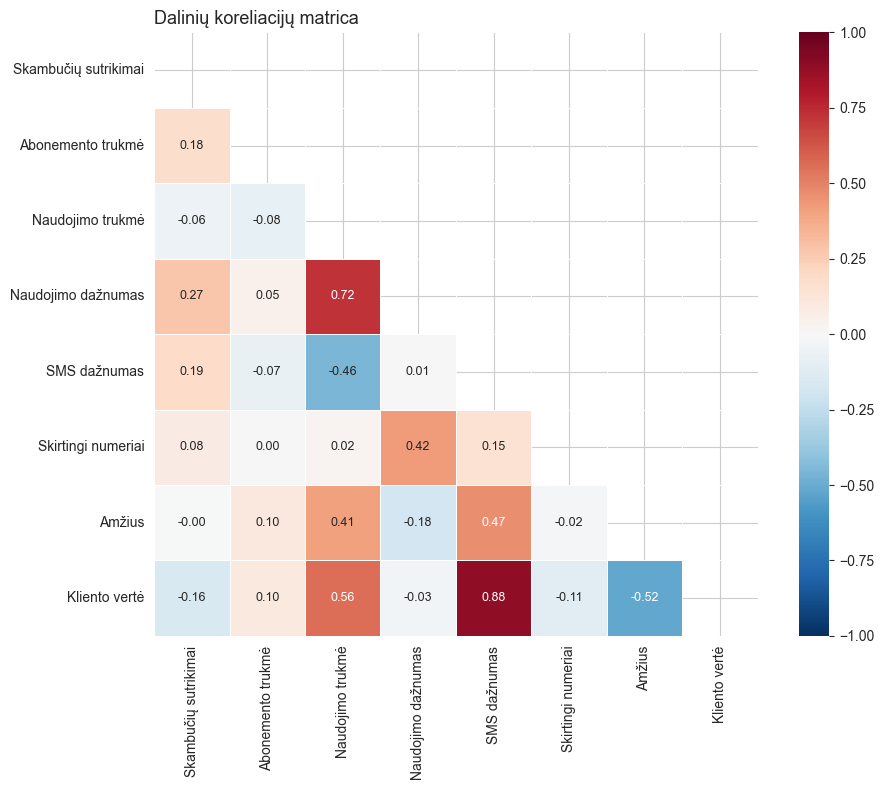

In [ ]:
cols = numeric_values.columns.tolist()
n    = len(cols)
pcor_mat = pd.DataFrame(np.eye(n), index=cols, columns=cols)

for i, x in enumerate(cols):
    for j, y in enumerate(cols):
        if i < j:
            covs = [c for c in cols if c not in [x, y]]
            r = partial_corr(data=numeric_values, x=x, y=y,
                             covar=covs, method='spearman')['r'].values[0]
            pcor_mat.loc[x, y] = r
            pcor_mat.loc[y, x] = r

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pcor_mat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 9}, vmin=-1, vmax=1, ax=ax)
ax.set_title('Dalinių koreliacijų matrica', fontsize=13, loc='left')
plt.tight_layout()
plt.show()

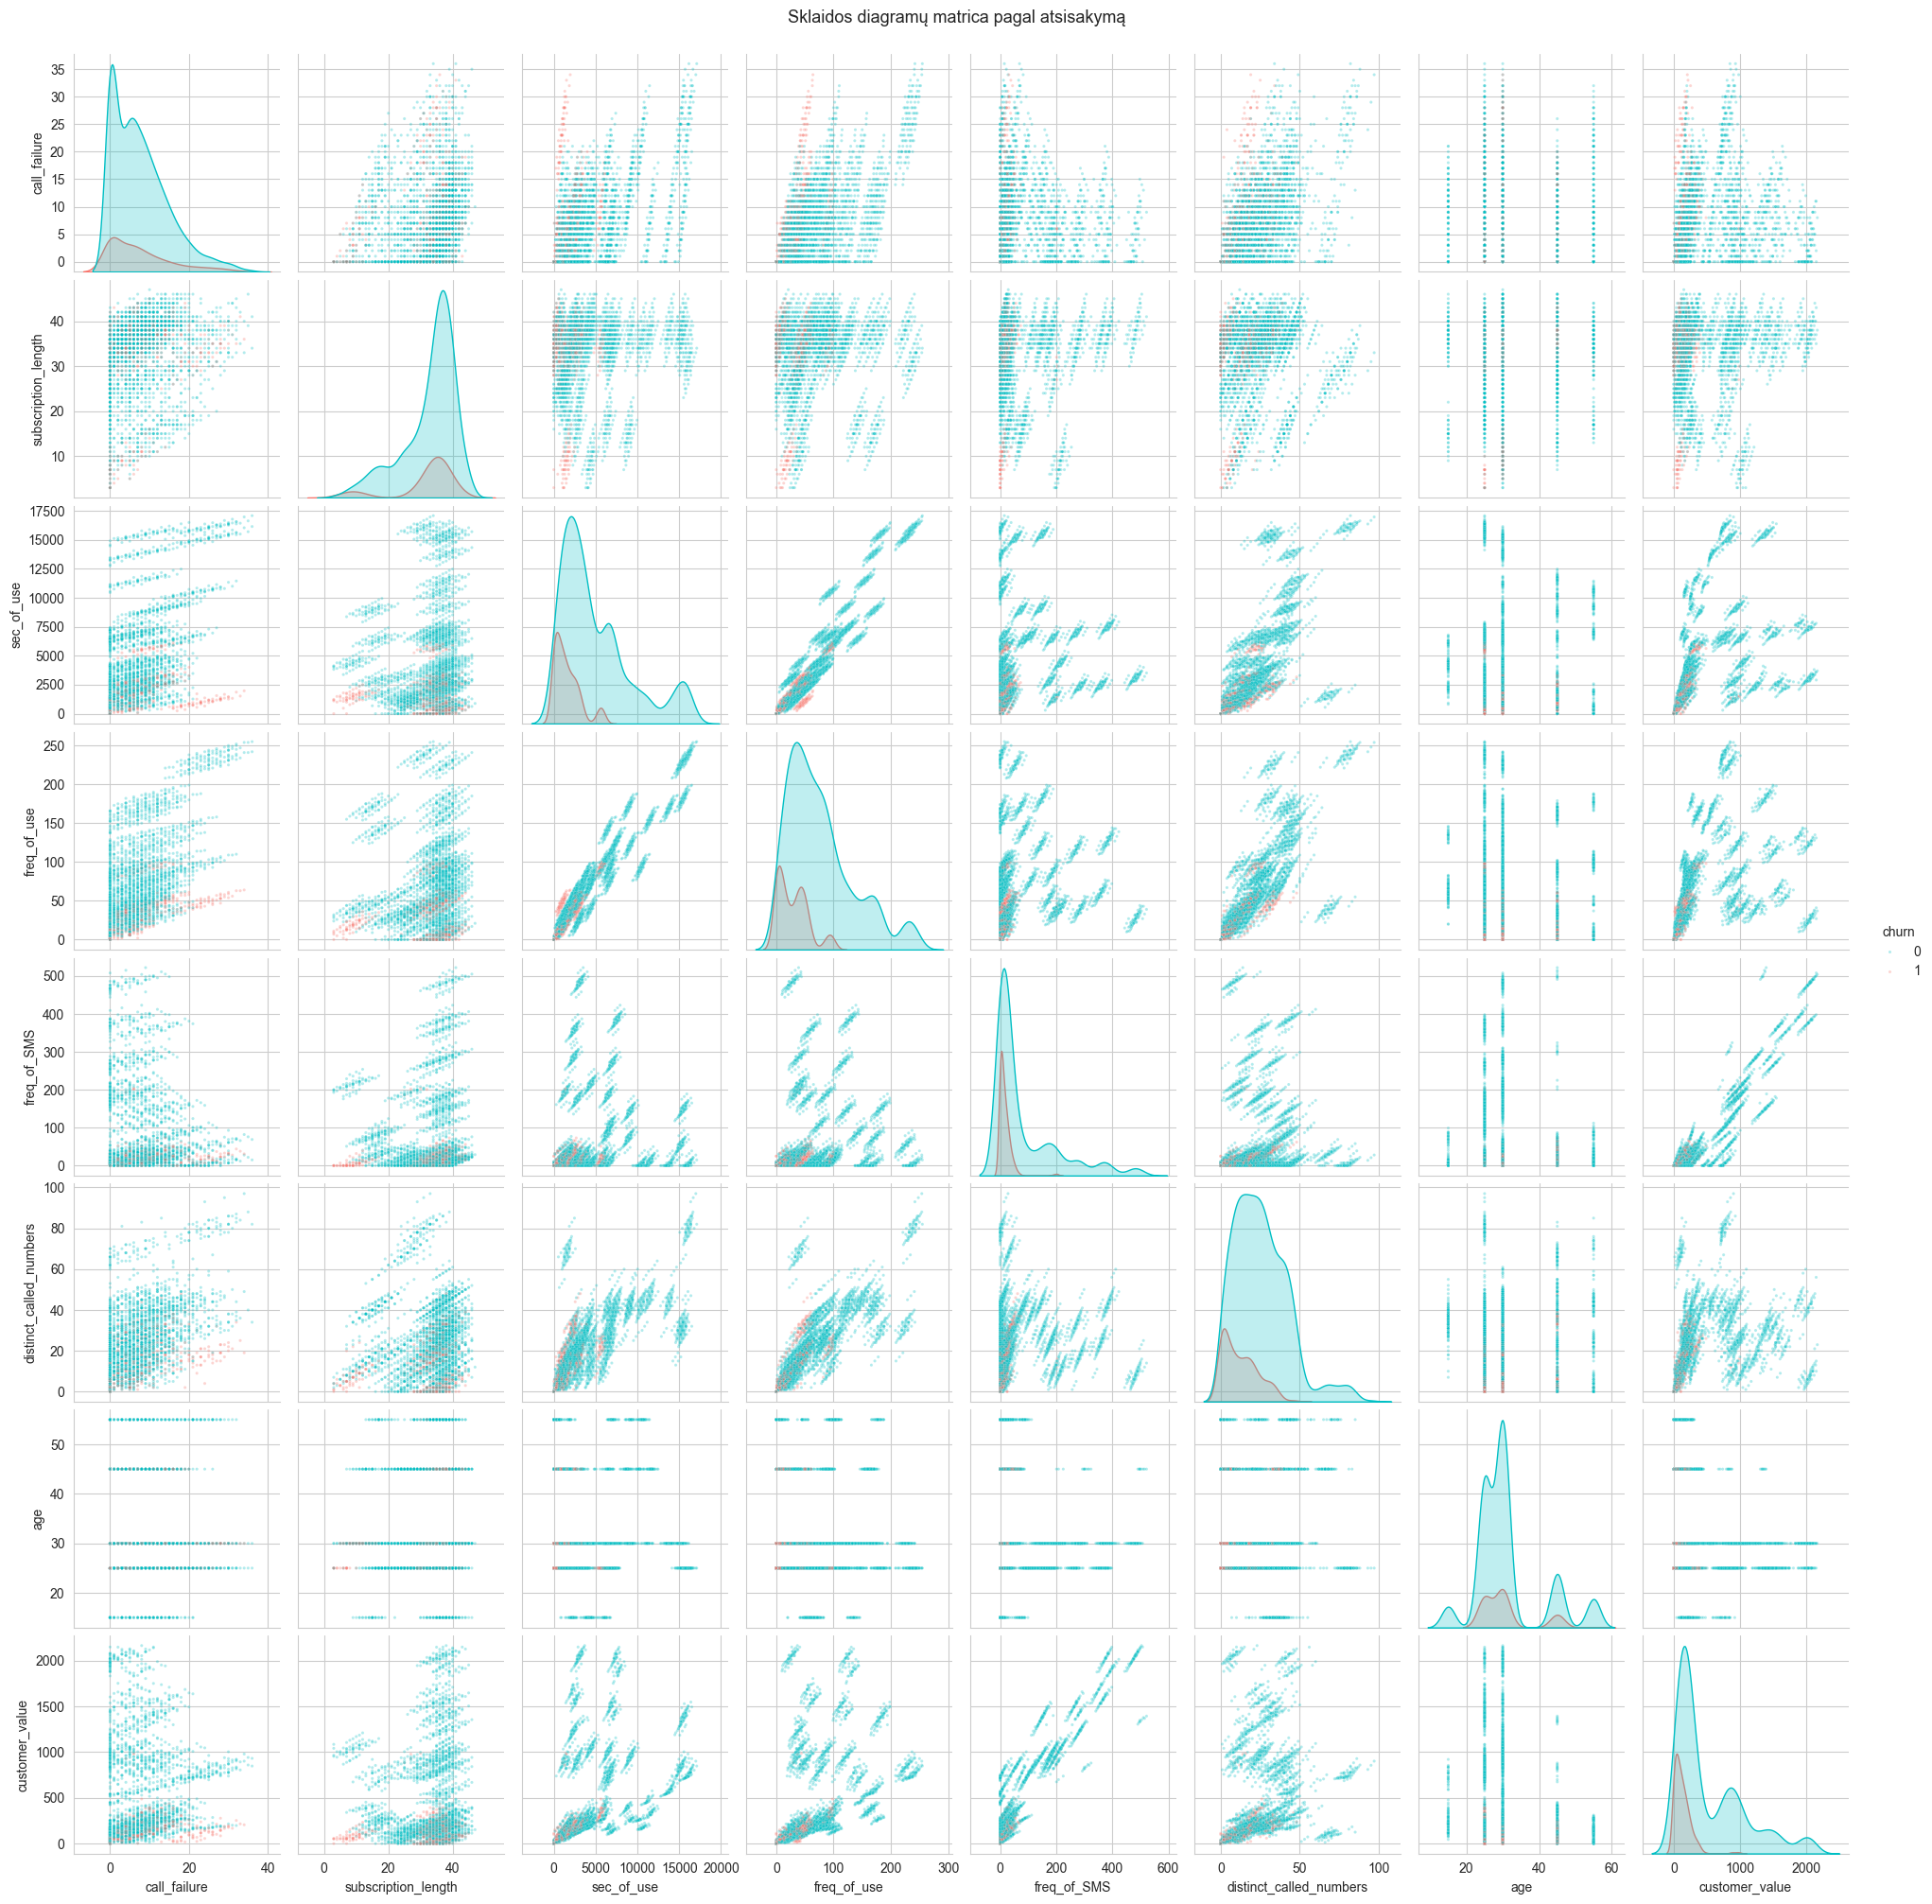

In [ ]:
scatter_df = churn_data.select_dtypes(include='number').copy()
scatter_df['churn'] = churn_data['churn'].astype(str)

g = sns.pairplot(scatter_df, hue='churn',
                 plot_kws={'alpha': 0.3, 's': 5},
                 diag_kind='kde',
                 palette=COLOR)
g.fig.suptitle('Sklaidos diagramų matrica pagal atsisakymą', y=1.01, fontsize=13)
plt.show()

# Kategorinių kintamųjų tvarkymas

In [17]:
churn_data2 = churn_data[
    churn_data['charge_amount'].astype(str).isin(['0', '1', '2', '3'])
].copy()

In [18]:
churn_data2['age_group2'] = churn_data2['age_group'].astype(str).apply(
    lambda x: '1-2' if x in ['1', '2'] else '3-5'
).astype('category')

print(pd.crosstab(churn_data2['age_group2'], churn_data2['churn']))

churn          0    1
age_group2           
1-2          949  184
3-5         1536  310


In [19]:
print(churn_data2.dtypes)

call_failure                  int64
complains                  category
subscription_length           int64
charge_amount              category
sec_of_use                    int64
freq_of_use                   int64
freq_of_SMS                   int64
distinct_called_numbers       int64
age_group                  category
tariff_plan                category
status                     category
age                           int64
customer_value              float64
churn                      category
age_group2                 category
dtype: object


# Binarinio atsako modeliai
## Mokymo ir testavimo aibės

In [20]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    churn_data2, test_size=0.2, stratify=churn_data2['churn'], random_state=1
)
train_data = train_data.sample(frac=1, random_state=1).reset_index(drop=True)
test_data  = test_data.sample(frac=1,  random_state=1).reset_index(drop=True)

print(f'Mokymo aibė:   {len(train_data)} eilučių')
print(f'Testavimo aibė: {len(test_data)} eilučių')
print('\nChurn pasiskirstymas mokymo aibėje:')
print(train_data['churn'].value_counts().sort_index())
print('\nChurn pasiskirstymas testavimo aibėje:')
print(test_data['churn'].value_counts().sort_index())

Mokymo aibė:   2383 eilučių
Testavimo aibė: 596 eilučių

Churn pasiskirstymas mokymo aibėje:
churn
0    1988
1     395
Name: count, dtype: int64

Churn pasiskirstymas testavimo aibėje:
churn
0    497
1     99
Name: count, dtype: int64


In [35]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_curve, auc, confusion_matrix
import patsy

_formulas = {}

def fit_glm(formula, data, link='logit'):
    family_map = {
        'logit':   sm.families.Binomial(sm.families.links.Logit()),
        'probit':  sm.families.Binomial(sm.families.links.Probit()),
        'cloglog': sm.families.Binomial(sm.families.links.CLogLog()),
    }
    df = _prep(data)
    y, X = patsy.dmatrices(formula, data=df, return_type='dataframe')
    mdl = sm.GLM(y, X, family=family_map[link]).fit()
    _formulas[id(mdl)] = X.design_info
    return mdl


def _prep(df):
    d = df.copy()
    for col in d.select_dtypes('category').columns:
        d[col] = d[col].astype(str)
    d['churn'] = d['churn'].astype(str).astype(int)
    return d


def _predict(mdl, new_df):
    design_info = _formulas[id(mdl)]
    X_new = patsy.build_design_matrices([design_info], _prep(new_df), return_type='dataframe')[0]
    return mdl.predict(X_new)


def cook_plot(mdl, ax=None):
    cooks = mdl.get_influence().cooks_distance[0]
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3))
    ax.scatter(range(len(cooks)), cooks, color='blue', alpha=0.7, s=20)
    ax.set_xlabel('Eilės numeris')
    ax.set_ylabel('Cook mato atstumas')
    return ax


def pearson_plot(mdl, ax=None):
    rp = mdl.resid_pearson
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3))
    ax.scatter(range(len(rp)), rp, color='blue', alpha=0.7, s=20)
    ax.set_xlabel('Eilės numeris')
    ax.set_ylabel('Pirsono išskirtys')
    return ax


def ROC_plot(mdl, test_df, ax=None):
    probs  = _predict(mdl, test_df)
    y_true = _prep(test_df)['churn']
    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc = auc(fpr, tpr)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(1 - fpr, tpr, color='blue', lw=1.5)
    ax.plot([1, 0], [0, 1], 'r--')
    ax.set_xlabel('Specifiškumas (Specificity)')
    ax.set_ylabel('Jautrumas (Sensitivity)')
    ax.set_title(f'ROC kreivė (AUC = {roc_auc:.3f})')
    return ax


def ROC_youden_plot(mdl, train_df, test_df):
    probs_train = _predict(mdl, train_df)
    y_train = _prep(train_df)['churn']
    fpr_tr, tpr_tr, thr_tr = roc_curve(y_train, probs_train)
    best_idx = np.argmax(tpr_tr - fpr_tr)
    best_thr = thr_tr[best_idx]
    print(f'Optimalus slenkstis pagal Youdeno indeksą: {best_thr:.4f}')
    print(f'Jautrumas  (Sensitivity): {tpr_tr[best_idx]:.4f}')
    print(f'Specifiškumas (Specificity): {1 - fpr_tr[best_idx]:.4f}')

    probs_test = _predict(mdl, test_df)
    y_true     = _prep(test_df)['churn']
    preds      = (probs_test >= best_thr).astype(int)
    cm  = confusion_matrix(y_true, preds)
    pct = cm / cm.sum(axis=1, keepdims=True)
    print('\nKonfuzijos matrica:')
    print(pd.DataFrame(cm,  index=['Tikra 0','Tikra 1'], columns=['Prog. 0','Prog. 1']))
    print('\nProcentais:')
    print(pd.DataFrame(pct.round(2), index=['Tikra 0','Tikra 1'], columns=['Prog. 0','Prog. 1']))

    fpr, tpr, _ = roc_curve(y_true, probs_test)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(1 - fpr, tpr, color='blue', lw=1.5)
    ax.plot([1, 0], [0, 1], 'r--')
    ax.set_xlabel('Specifiškumas (Specificity)')
    ax.set_ylabel('Jautrumas (Sensitivity)')
    ax.set_title(f'ROC kreivė (AUC = {auc(fpr, tpr):.3f})')
    plt.show()
    return best_thr


def confusion_test(mdl, test_df, threshold=0.5):
    probs  = _predict(mdl, test_df)
    y_true = _prep(test_df)['churn']
    preds  = (probs >= threshold).astype(int)
    cm  = confusion_matrix(y_true, preds)
    pct = cm / cm.sum(axis=1, keepdims=True)
    print(pd.DataFrame(cm,  index=['Tikra 0','Tikra 1'], columns=['Prog. 0','Prog. 1']))
    print(pd.DataFrame(pct.round(2), index=['Tikra 0','Tikra 1'], columns=['Prog. 0','Prog. 1']))


def vif_table(df, feature_cols):
    X = pd.get_dummies(df[feature_cols].copy(), drop_first=True).astype(float)
    X = sm.add_constant(X)
    vif = pd.DataFrame({
        'feature': X.columns,
        'VIF':     [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })
    return vif[vif['feature'] != 'const'].reset_index(drop=True)


## SMOTE balansavimas

In [ ]:
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import LabelEncoder

np.random.seed(1)

feature_cols = [c for c in train_data.columns if c != 'churn']
cat_cols_smote = [c for c in feature_cols if train_data[c].dtype.name == 'category']
cat_idx = [feature_cols.index(c) for c in cat_cols_smote]

X = train_data[feature_cols].copy()
y = train_data['churn'].astype(str).astype(int)

le_store = {}
for col in cat_cols_smote:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_store[col] = le

smote = SMOTENC(categorical_features=cat_idx, random_state=1, sampling_strategy=1.0)
X_bal, y_bal = smote.fit_resample(X, y)

balanced_churn = pd.DataFrame(X_bal, columns=feature_cols)
balanced_churn['churn'] = y_bal

for col in cat_cols_smote:
    le = le_store[col]
    balanced_churn[col] = pd.Categorical(le.inverse_transform(
        balanced_churn[col].round().astype(int).clip(0, len(le.classes_) - 1)
    ))
balanced_churn['churn'] = balanced_churn['churn'].astype('category')

print('Balanced churn pasiskirstymas:')
print(balanced_churn['churn'].value_counts().sort_index())

Balanced churn pasiskirstymas:
churn
0    1988
1    1988
Name: count, dtype: int64


## Logit

Logit modelis su visais kintamaisiais ir kovariančių multikolinearumas balancuotam rinkiniui.

In [26]:
cat_cols_bal = [c for c in balanced_churn.columns
                if balanced_churn[c].dtype.name == 'category' and c != 'churn']

for col in cat_cols_bal:
    print(f'\n--- Kryžminė lentelė kintamajam: {col} ---')
    print(pd.crosstab(balanced_churn[col], balanced_churn['churn'],
                      rownames=[col], colnames=['Churn']))


--- Kryžminė lentelė kintamajam: complains ---
Churn         0     1
complains            
0          1967  1185
1            21   803

--- Kryžminė lentelė kintamajam: charge_amount ---
Churn             0     1
charge_amount            
0              1080  1735
1               459   149
2               288    92
3               161    12

--- Kryžminė lentelė kintamajam: age_group ---
Churn        0     1
age_group           
1           95     0
2          652   636
3          914  1056
4          225   294
5          102     2

--- Kryžminė lentelė kintamajam: tariff_plan ---
Churn           0     1
tariff_plan            
1            1856  1962
2             132    26

--- Kryžminė lentelė kintamajam: status ---
Churn      0     1
status            
1       1646   469
2        342  1519

--- Kryžminė lentelė kintamajam: age_group2 ---
Churn          0     1
age_group2            
1-2          747   596
3-5         1241  1392


In [ ]:
logit_mdl = fit_glm(
    'churn ~ subscription_length + sec_of_use + freq_of_use + freq_of_SMS + '
    'distinct_called_numbers + complains + status + charge_amount + age_group2',
    balanced_churn, link='logit'
)
print(logit_mdl.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 3976
Model:                            GLM   Df Residuals:                     3964
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1344.3
Date:                Sat, 14 Mar 2026   Deviance:                       2688.7
Time:                        23:26:36   Pearson chi2:                 4.11e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.5084
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [29]:
print('\nVIF:')
print(vif_table(balanced_churn,
    ['subscription_length','sec_of_use','freq_of_use','freq_of_SMS',
     'distinct_called_numbers','charge_amount']))


VIF:
                   feature        VIF
0      subscription_length   1.052405
1               sec_of_use  11.119262
2              freq_of_use  13.976286
3              freq_of_SMS   1.111022
4  distinct_called_numbers   2.487722
5          charge_amount_1   1.159419
6          charge_amount_2   1.150831
7          charge_amount_3   1.166387


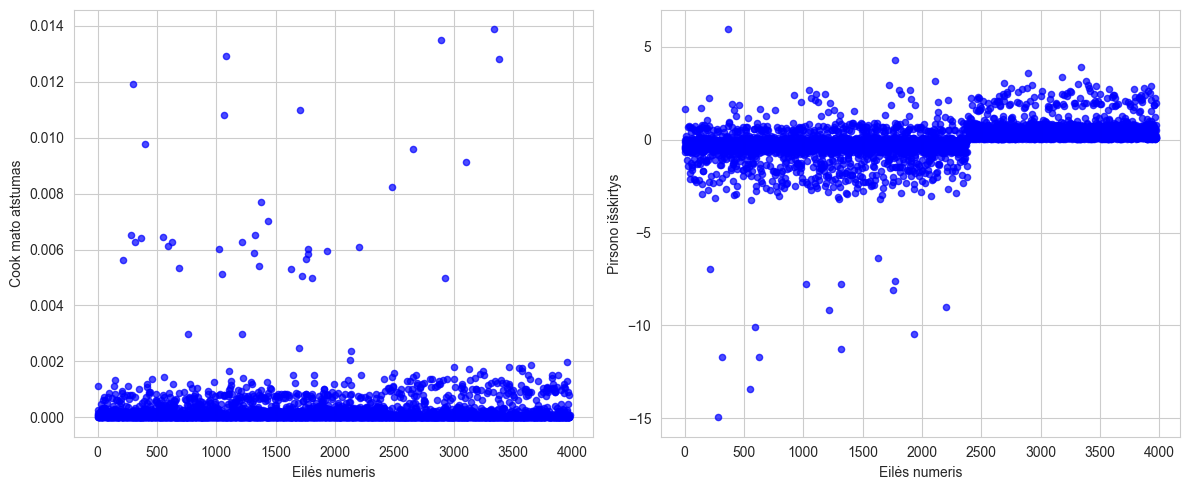

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cook_plot(logit_mdl, ax=axes[0])
pearson_plot(logit_mdl, ax=axes[1])
plt.tight_layout()
plt.show()

### Logit (SMOTE)

In [37]:
logit_mdl_smote = fit_glm(
    'churn ~ subscription_length + freq_of_SMS + distinct_called_numbers + '
    'complains + status + charge_amount + age_group2',
    balanced_churn, link='logit'
)
print(logit_mdl_smote.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 3976
Model:                            GLM   Df Residuals:                     3966
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1347.1
Date:                Sat, 14 Mar 2026   Deviance:                       2694.2
Time:                        23:50:23   Pearson chi2:                 4.25e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.5077
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

         Prog. 0  Prog. 1
Tikra 0      431       66
Tikra 1       14       85
         Prog. 0  Prog. 1
Tikra 0     0.87     0.13
Tikra 1     0.14     0.86


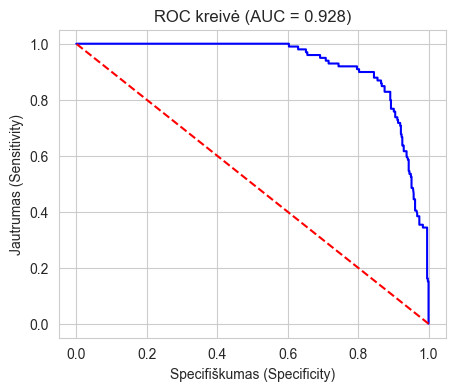

In [38]:
confusion_test(logit_mdl_smote, test_data)
ROC_plot(logit_mdl_smote, test_data)
plt.show()

In [40]:
logit_mdl_smote_gamma = fit_glm(
    'churn ~ subscription_length + freq_of_SMS + distinct_called_numbers + '
    'complains + status + charge_amount + age_group2 + freq_of_use:age_group2',
    balanced_churn, link='logit'
)
print(logit_mdl_smote_gamma.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 3976
Model:                            GLM   Df Residuals:                     3964
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1265.3
Date:                Sat, 14 Mar 2026   Deviance:                       2530.5
Time:                        23:52:40   Pearson chi2:                 3.57e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.5276
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

         Prog. 0  Prog. 1
Tikra 0      430       67
Tikra 1       16       83
         Prog. 0  Prog. 1
Tikra 0     0.87     0.13
Tikra 1     0.16     0.84


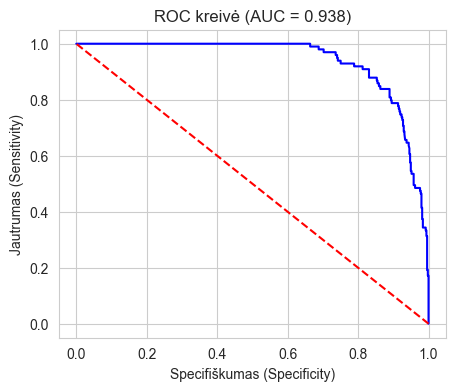

In [41]:
confusion_test(logit_mdl_smote_gamma, test_data)
ROC_plot(logit_mdl_smote_gamma, test_data)
plt.show()

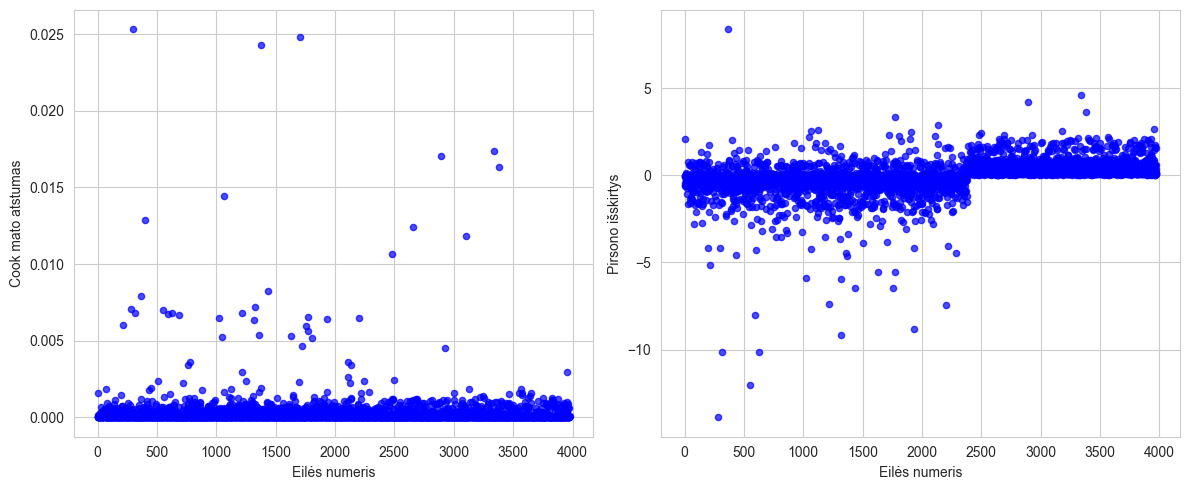

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cook_plot(logit_mdl_smote_gamma, ax=axes[0])
pearson_plot(logit_mdl_smote_gamma, ax=axes[1])
plt.tight_layout()
plt.show()

### Logit (Youden - sec_of_use)

In [44]:
logit_mdl_yd = fit_glm(
    'churn ~ subscription_length + sec_of_use + freq_of_use + freq_of_SMS + '
    'distinct_called_numbers + complains + status + charge_amount + age_group2',
    train_data, link='logit'
)
print(logit_mdl_yd.summary())
print('\nVIF:')
print(vif_table(train_data,
    ['subscription_length','sec_of_use','freq_of_use','freq_of_SMS',
     'distinct_called_numbers','charge_amount']))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 2383
Model:                            GLM   Df Residuals:                     2371
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -571.49
Date:                Sat, 14 Mar 2026   Deviance:                       1143.0
Time:                        23:54:07   Pearson chi2:                 1.74e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.3420
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

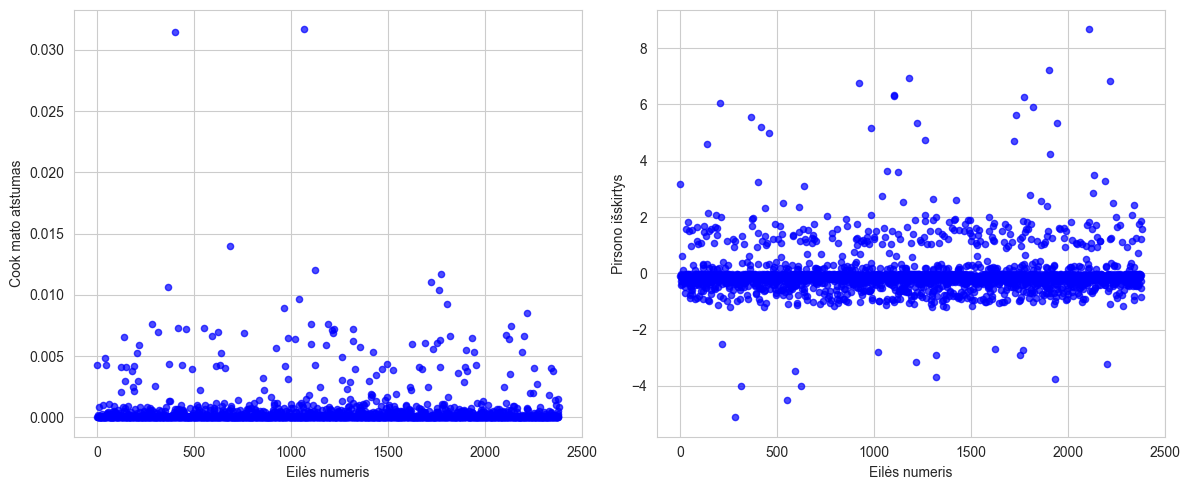

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cook_plot(logit_mdl_yd, ax=axes[0])
pearson_plot(logit_mdl_yd, ax=axes[1])
plt.tight_layout()
plt.show()

In [47]:
logit_mdl_su = fit_glm(
    'churn ~ subscription_length + sec_of_use + freq_of_SMS + '
    'distinct_called_numbers + complains + status',
    train_data, link='logit'
)
print(logit_mdl_su.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 2383
Model:                            GLM   Df Residuals:                     2376
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -582.00
Date:                Sat, 14 Mar 2026   Deviance:                       1164.0
Time:                        23:54:34   Pearson chi2:                 1.70e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.3362
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

Optimalus slenkstis pagal Youdeno indeksą: 0.1643
Jautrumas  (Sensitivity): 0.8987
Specifiškumas (Specificity): 0.8270

Konfuzijos matrica:
         Prog. 0  Prog. 1
Tikra 0      429       68
Tikra 1       12       87

Procentais:
         Prog. 0  Prog. 1
Tikra 0     0.86     0.14
Tikra 1     0.12     0.88


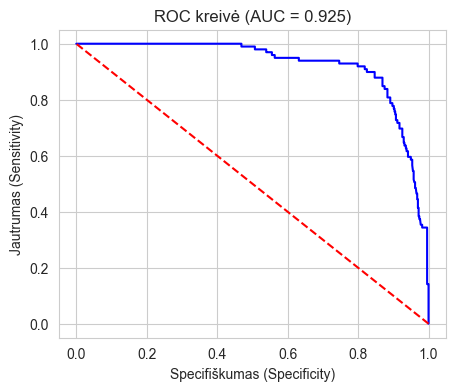

np.float64(0.16434932774413596)

In [48]:
ROC_youden_plot(logit_mdl_su, train_data, test_data)

In [49]:
logit_mdl_su_gamma = fit_glm(
    'churn ~ subscription_length + sec_of_use + freq_of_SMS + '
    'distinct_called_numbers + complains + status + subscription_length:status',
    train_data, link='logit'
)

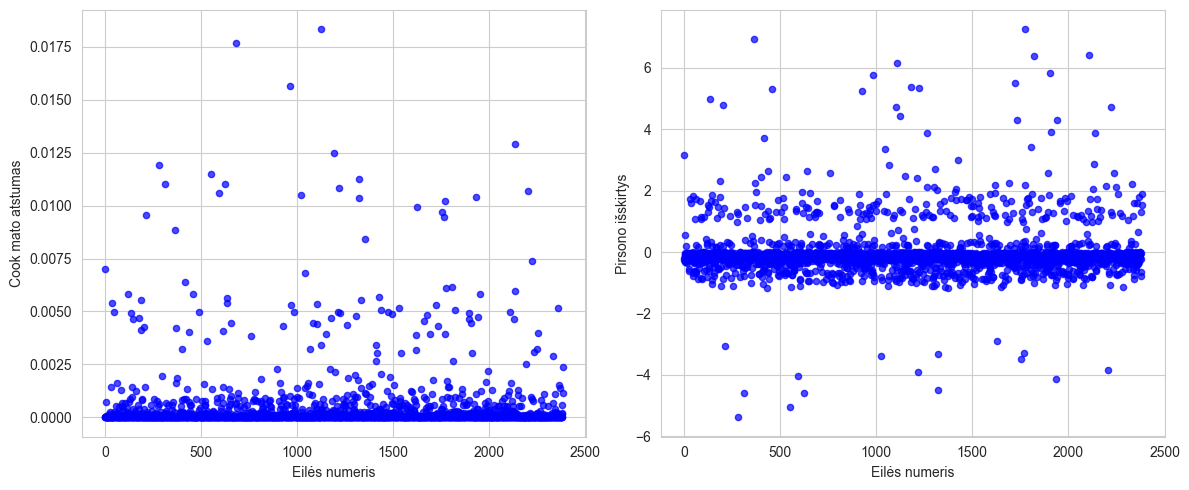

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cook_plot(logit_mdl_su, ax=axes[0])
pearson_plot(logit_mdl_su, ax=axes[1])
plt.tight_layout()
plt.show()

### Logit (Youden - freq_of_use)

In [52]:
logit_mdl_fu = fit_glm(
    'churn ~ subscription_length + freq_of_use + freq_of_SMS + complains + status',
    train_data, link='logit'
)
print(logit_mdl_fu.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 2383
Model:                            GLM   Df Residuals:                     2377
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -578.45
Date:                Sat, 14 Mar 2026   Deviance:                       1156.9
Time:                        23:56:15   Pearson chi2:                 1.84e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.3381
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.5089    

Optimalus slenkstis pagal Youdeno indeksą: 0.1708
Jautrumas  (Sensitivity): 0.9063
Specifiškumas (Specificity): 0.8325

Konfuzijos matrica:
         Prog. 0  Prog. 1
Tikra 0      431       66
Tikra 1       10       89

Procentais:
         Prog. 0  Prog. 1
Tikra 0     0.87     0.13
Tikra 1     0.10     0.90


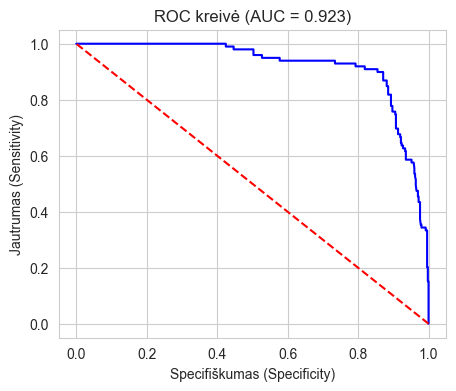

np.float64(0.17077163119470312)

In [53]:
ROC_youden_plot(logit_mdl_fu, train_data, test_data)

In [54]:
logit_mdl_fu_gamma = fit_glm(
    'churn ~ subscription_length + freq_of_use + freq_of_SMS + '
    'complains + status + subscription_length:status',
    train_data, link='logit'
)

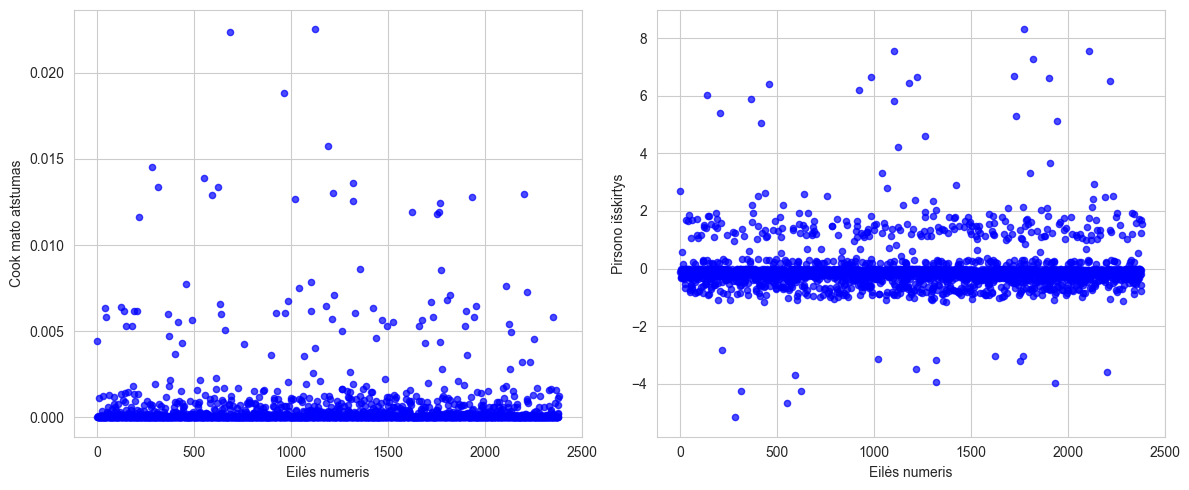

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cook_plot(logit_mdl_fu, ax=axes[0])
pearson_plot(logit_mdl_fu, ax=axes[1])
plt.tight_layout()
plt.show()

## Probit

### Balansavimas naudojantis SMOTE

In [57]:
probit_model = fit_glm(
    'churn ~ call_failure + complains + subscription_length + charge_amount + '
    'sec_of_use + freq_of_use + freq_of_SMS + distinct_called_numbers + status + age_group2',
    balanced_churn, link='probit'
)
print(probit_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 3976
Model:                            GLM   Df Residuals:                     3963
Model Family:                Binomial   Df Model:                           12
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1295.1
Date:                Sat, 14 Mar 2026   Deviance:                       2590.1
Time:                        23:58:30   Pearson chi2:                 3.91e+03
No. Iterations:                    10   Pseudo R-squ. (CS):             0.5204
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [58]:
print(vif_table(balanced_churn,
    ['call_failure','subscription_length','charge_amount','sec_of_use',
     'freq_of_use','freq_of_SMS','distinct_called_numbers']))

                   feature        VIF
0             call_failure   1.763319
1      subscription_length   1.096700
2               sec_of_use  13.875638
3              freq_of_use  18.268124
4              freq_of_SMS   1.125733
5  distinct_called_numbers   2.490685
6          charge_amount_1   1.160242
7          charge_amount_2   1.179297
8          charge_amount_3   1.208949


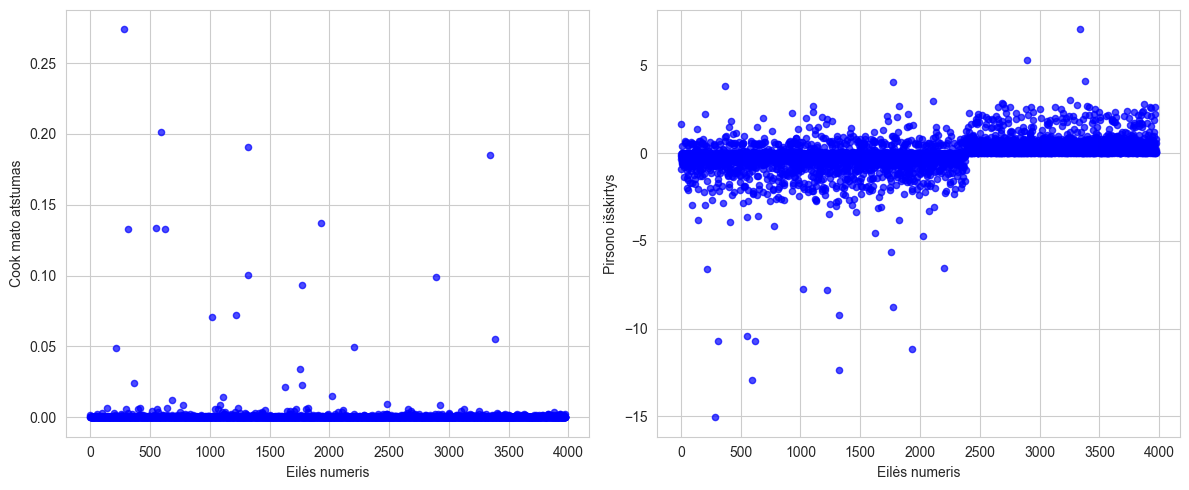

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cook_plot(probit_model, ax=axes[0])
pearson_plot(probit_model, ax=axes[1])
plt.tight_layout()
plt.show()

In [62]:
probit_model1 = fit_glm(
    'churn ~ call_failure + complains + subscription_length + charge_amount + '
    'sec_of_use + freq_of_SMS + distinct_called_numbers + status + age_group2',
    balanced_churn, link='probit'
)
print(probit_model1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 3976
Model:                            GLM   Df Residuals:                     3964
Model Family:                Binomial   Df Model:                           11
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1324.3
Date:                Sat, 14 Mar 2026   Deviance:                       2648.6
Time:                        23:59:05   Pearson chi2:                 5.06e+03
No. Iterations:                    10   Pseudo R-squ. (CS):             0.5133
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [63]:
probit_model2 = fit_glm(
    'churn ~ call_failure + complains + subscription_length + charge_amount + '
    'freq_of_use + freq_of_SMS + distinct_called_numbers + status + age_group2',
    balanced_churn, link='probit'
)
print(probit_model2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 3976
Model:                            GLM   Df Residuals:                     3964
Model Family:                Binomial   Df Model:                           11
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1315.5
Date:                Sun, 15 Mar 2026   Deviance:                       2630.9
Time:                        00:00:03   Pearson chi2:                 4.40e+03
No. Iterations:                    10   Pseudo R-squ. (CS):             0.5155
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [64]:
print(pd.DataFrame({
    'Model': ['probit_model1', 'probit_model2'],
    'AIC':   [probit_model1.aic, probit_model2.aic],
    'BIC':   [probit_model1.bic, probit_model2.bic],
}))

           Model          AIC           BIC
0  probit_model1  2672.614158 -30205.142976
1  probit_model2  2654.940491 -30222.816644


In [65]:
confusion_test(probit_model2, test_data)

         Prog. 0  Prog. 1
Tikra 0      427       70
Tikra 1       15       84
         Prog. 0  Prog. 1
Tikra 0     0.86     0.14
Tikra 1     0.15     0.85


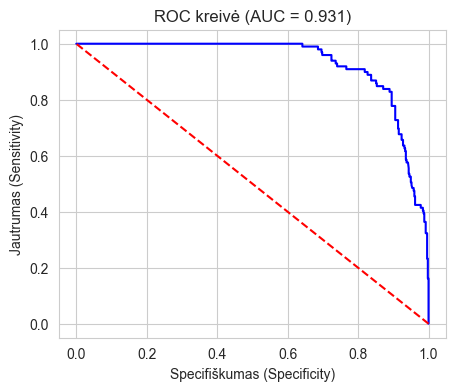

In [66]:
ROC_plot(probit_model2, test_data)
plt.show()

In [67]:
probit_model2_interaction = fit_glm(
    'churn ~ call_failure + complains + subscription_length + charge_amount + '
    'freq_of_use + freq_of_SMS + distinct_called_numbers + status + age_group2 + '
    'call_failure:complains',
    balanced_churn, link='probit'
)
print(probit_model2_interaction.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 3976
Model:                            GLM   Df Residuals:                     3963
Model Family:                Binomial   Df Model:                           12
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1307.1
Date:                Sun, 15 Mar 2026   Deviance:                       2614.3
Time:                        00:01:10   Pearson chi2:                 4.90e+03
No. Iterations:                    10   Pseudo R-squ. (CS):             0.5175
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [68]:
confusion_test(probit_model2_interaction, test_data)

         Prog. 0  Prog. 1
Tikra 0      426       71
Tikra 1       15       84
         Prog. 0  Prog. 1
Tikra 0     0.86     0.14
Tikra 1     0.15     0.85


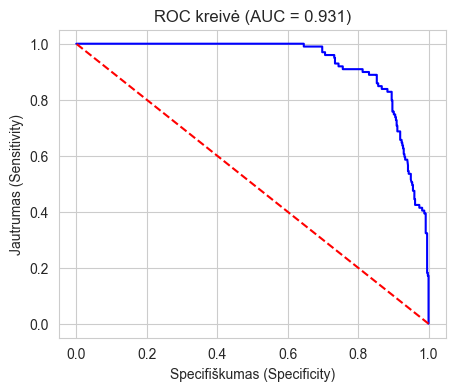

In [69]:
ROC_plot(probit_model2_interaction, test_data)
plt.show()

### Balansavimas naudojantis slenksčiu ir Youden indeksu

In [70]:
probit_model3 = fit_glm(
    'churn ~ call_failure + complains + subscription_length + charge_amount + '
    'sec_of_use + freq_of_use + freq_of_SMS + distinct_called_numbers + status + age_group2',
    train_data, link='probit'
)
print(probit_model3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 2383
Model:                            GLM   Df Residuals:                     2370
Model Family:                Binomial   Df Model:                           12
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -541.82
Date:                Sun, 15 Mar 2026   Deviance:                       1083.6
Time:                        00:01:44   Pearson chi2:                 1.59e+03
No. Iterations:                    10   Pseudo R-squ. (CS):             0.3582
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [71]:
print(vif_table(train_data,
    ['call_failure','subscription_length','charge_amount','sec_of_use',
     'freq_of_use','freq_of_SMS','distinct_called_numbers']))

                    feature        VIF
0              call_failure   1.935190
1       subscription_length   1.049486
2                sec_of_use  12.582468
3               freq_of_use  16.476748
4               freq_of_SMS   1.076479
5   distinct_called_numbers   2.245206
6           charge_amount_1   1.196095
7           charge_amount_2   1.316828
8           charge_amount_3   1.355977
9           charge_amount_4        NaN
10          charge_amount_5        NaN
11          charge_amount_6        NaN
12          charge_amount_7        NaN
13          charge_amount_8        NaN
14          charge_amount_9        NaN
15         charge_amount_10        NaN


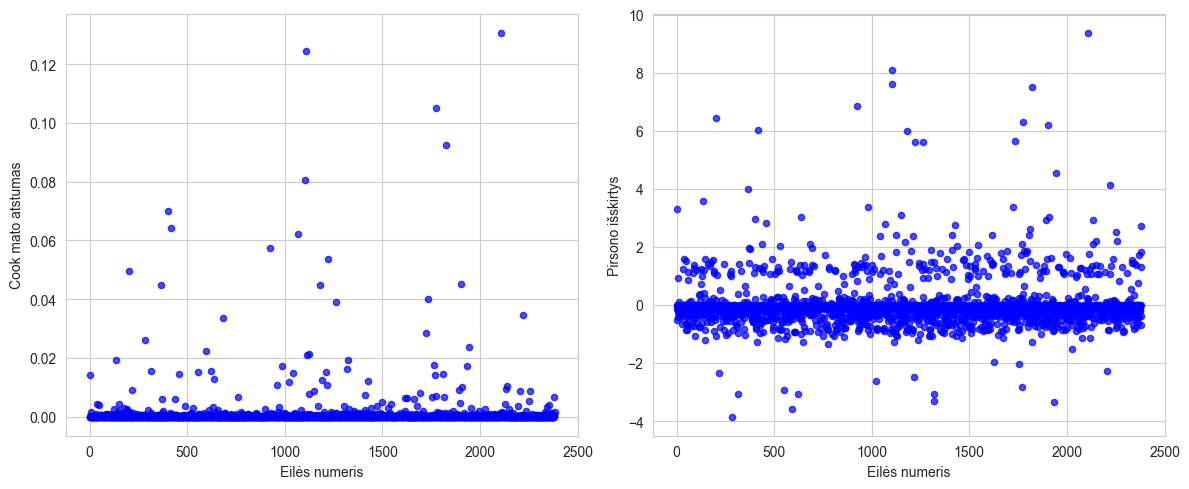

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cook_plot(probit_model3, ax=axes[0])
pearson_plot(probit_model3, ax=axes[1])
plt.tight_layout()
plt.show()

In [74]:
probit_model31 = fit_glm(
    'churn ~ call_failure + complains + subscription_length + '
    'sec_of_use + freq_of_SMS + distinct_called_numbers + status',
    train_data, link='probit'
)
print(probit_model31.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 2383
Model:                            GLM   Df Residuals:                     2375
Model Family:                Binomial   Df Model:                            7
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -566.57
Date:                Sun, 15 Mar 2026   Deviance:                       1133.1
Time:                        00:03:25   Pearson chi2:                 1.54e+03
No. Iterations:                    10   Pseudo R-squ. (CS):             0.3447
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [75]:
probit_model32 = fit_glm(
    'churn ~ call_failure + complains + subscription_length + '
    'freq_of_use + freq_of_SMS + distinct_called_numbers + status',
    train_data, link='probit'
)
print(probit_model32.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 2383
Model:                            GLM   Df Residuals:                     2375
Model Family:                Binomial   Df Model:                            7
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -556.27
Date:                Sun, 15 Mar 2026   Deviance:                       1112.5
Time:                        00:03:34   Pearson chi2:                 1.66e+03
No. Iterations:                    10   Pseudo R-squ. (CS):             0.3504
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [76]:
print(pd.DataFrame({
    'Model': ['probit_model31', 'probit_model32'],
    'AIC':   [probit_model31.aic, probit_model32.aic],
    'BIC':   [probit_model31.bic, probit_model32.bic],
}))

            Model          AIC           BIC
0  probit_model31  1149.148198 -17335.126060
1  probit_model32  1128.539100 -17355.735158


Optimalus slenkstis pagal Youdeno indeksą: 0.1924
Jautrumas  (Sensitivity): 0.9063
Specifiškumas (Specificity): 0.8365

Konfuzijos matrica:
         Prog. 0  Prog. 1
Tikra 0      430       67
Tikra 1       14       85

Procentais:
         Prog. 0  Prog. 1
Tikra 0     0.87     0.13
Tikra 1     0.14     0.86


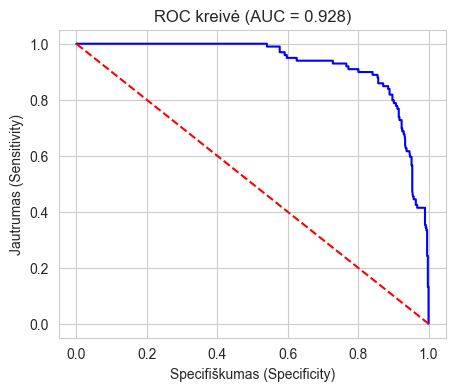

np.float64(0.19241010342476594)

In [77]:
ROC_youden_plot(probit_model32, train_data, test_data)

In [78]:
probit_model32_interaction = fit_glm(
    'churn ~ call_failure + complains + subscription_length + '
    'freq_of_use + freq_of_SMS + distinct_called_numbers + status + '
    'call_failure:complains',
    train_data, link='probit'
)
print(probit_model32_interaction.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 2383
Model:                            GLM   Df Residuals:                     2374
Model Family:                Binomial   Df Model:                            8
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -553.34
Date:                Sun, 15 Mar 2026   Deviance:                       1106.7
Time:                        00:04:06   Pearson chi2:                 1.62e+03
No. Iterations:                    10   Pseudo R-squ. (CS):             0.3519
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

Optimalus slenkstis pagal Youdeno indeksą: 0.1765
Jautrumas  (Sensitivity): 0.9139
Specifiškumas (Specificity): 0.8260

Konfuzijos matrica:
         Prog. 0  Prog. 1
Tikra 0      423       74
Tikra 1       11       88

Procentais:
         Prog. 0  Prog. 1
Tikra 0     0.85     0.15
Tikra 1     0.11     0.89


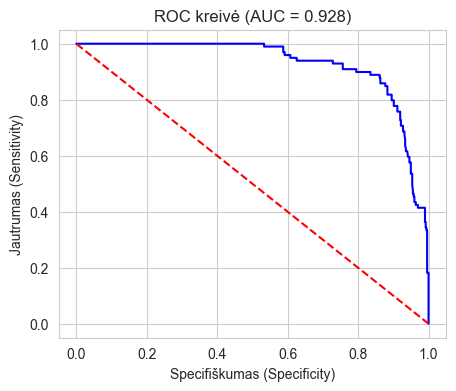

np.float64(0.17654154803666372)

In [79]:
ROC_youden_plot(probit_model32_interaction, train_data, test_data)

## Cloglog
### Cloglog modelis ant originalių duomenų

In [80]:
cloglog_model_original = fit_glm(
    'churn ~ call_failure + complains + subscription_length + charge_amount + '
    'sec_of_use + freq_of_use + freq_of_SMS + distinct_called_numbers + status + age_group2',
    train_data, link='cloglog'
)
print(cloglog_model_original.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 2383
Model:                            GLM   Df Residuals:                     2370
Model Family:                Binomial   Df Model:                           12
Link Function:                CLogLog   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -551.73
Date:                Sun, 15 Mar 2026   Deviance:                       1103.5
Time:                        00:06:31   Pearson chi2:                 1.57e+03
No. Iterations:                    13   Pseudo R-squ. (CS):             0.3528
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

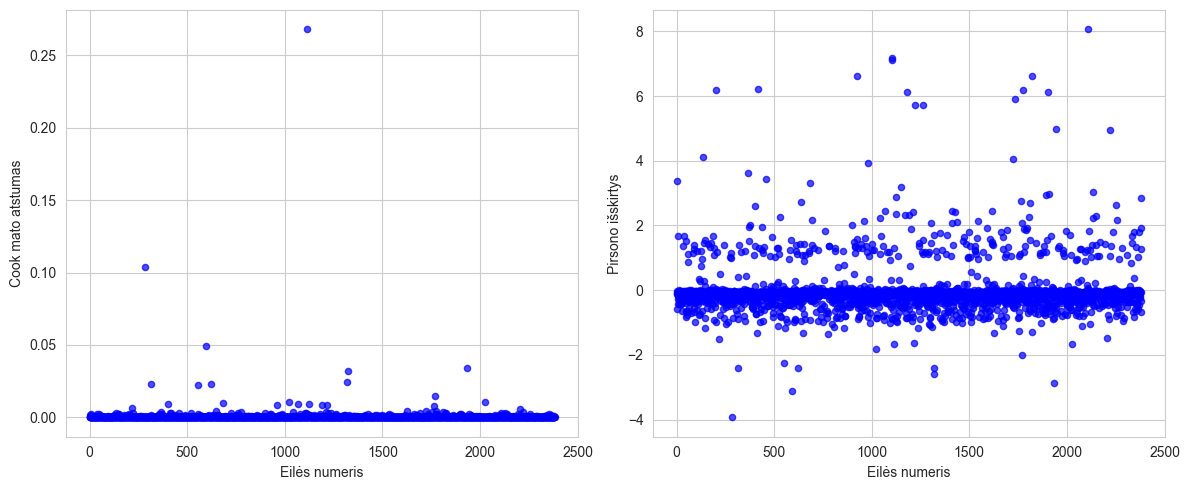

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cook_plot(cloglog_model_original, ax=axes[0])
pearson_plot(cloglog_model_original, ax=axes[1])
plt.tight_layout()
plt.show()

In [83]:
print(vif_table(train_data,
    ['call_failure','subscription_length','charge_amount','sec_of_use',
     'freq_of_use','freq_of_SMS','distinct_called_numbers']))

                    feature        VIF
0              call_failure   1.935190
1       subscription_length   1.049486
2                sec_of_use  12.582468
3               freq_of_use  16.476748
4               freq_of_SMS   1.076479
5   distinct_called_numbers   2.245206
6           charge_amount_1   1.196095
7           charge_amount_2   1.316828
8           charge_amount_3   1.355977
9           charge_amount_4        NaN
10          charge_amount_5        NaN
11          charge_amount_6        NaN
12          charge_amount_7        NaN
13          charge_amount_8        NaN
14          charge_amount_9        NaN
15         charge_amount_10        NaN


In [84]:
cloglog_model_original_freq_of_use = fit_glm(
    'churn ~ call_failure + complains + subscription_length + '
    'freq_of_use + freq_of_SMS + status',
    train_data, link='cloglog'
)
print(cloglog_model_original_freq_of_use.summary())
print('\nVIF:')
print(vif_table(train_data,
    ['call_failure','subscription_length','freq_of_use','freq_of_SMS']))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 2383
Model:                            GLM   Df Residuals:                     2376
Model Family:                Binomial   Df Model:                            6
Link Function:                CLogLog   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -568.42
Date:                Sun, 15 Mar 2026   Deviance:                       1136.8
Time:                        00:07:13   Pearson chi2:                 1.70e+03
No. Iterations:                    10   Pseudo R-squ. (CS):             0.3437
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.5997    

In [85]:
cloglog_model_original_sec_of_use = fit_glm(
    'churn ~ call_failure + complains + subscription_length + '
    'sec_of_use + freq_of_SMS + distinct_called_numbers + status',
    train_data, link='cloglog'
)
print(cloglog_model_original_sec_of_use.summary())
print('\nVIF:')
print(vif_table(train_data,
    ['call_failure','subscription_length','sec_of_use','freq_of_SMS','distinct_called_numbers']))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 2383
Model:                            GLM   Df Residuals:                     2375
Model Family:                Binomial   Df Model:                            7
Link Function:                CLogLog   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -588.59
Date:                Sun, 15 Mar 2026   Deviance:                       1177.2
Time:                        00:07:31   Pearson chi2:                 1.53e+03
No. Iterations:                    10   Pseudo R-squ. (CS):             0.3325
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [86]:
print(pd.DataFrame({
    'Model': ['cloglog_freq_of_use', 'cloglog_sec_of_use'],
    'AIC':   [cloglog_model_original_freq_of_use.aic, cloglog_model_original_sec_of_use.aic],
    'BIC':   [cloglog_model_original_freq_of_use.bic, cloglog_model_original_sec_of_use.bic],
}))

                 Model          AIC          BIC
0  cloglog_freq_of_use  1150.840863 -17339.20951
1   cloglog_sec_of_use  1193.177078 -17291.09718


         Prog. 0  Prog. 1
Tikra 0     1947       41
Tikra 1      233      162
         Prog. 0  Prog. 1
Tikra 0     0.98     0.02
Tikra 1     0.59     0.41


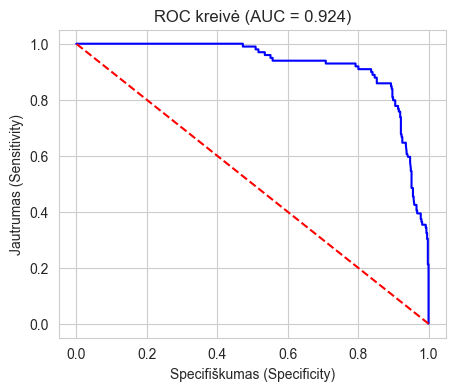

In [87]:
confusion_test(cloglog_model_original_freq_of_use, train_data)
ROC_plot(cloglog_model_original_freq_of_use, test_data)
plt.show()

In [88]:
cloglog_model_original_multi = fit_glm(
    'churn ~ call_failure + complains + freq_of_SMS + freq_of_use:status',
    train_data, link='cloglog'
)
print(cloglog_model_original_multi.summary())
print('\nVIF:')
print(vif_table(train_data, ['call_failure','freq_of_SMS']))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  churn   No. Observations:                 2383
Model:                            GLM   Df Residuals:                     2377
Model Family:                Binomial   Df Model:                            5
Link Function:                CLogLog   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -588.28
Date:                Sun, 15 Mar 2026   Deviance:                       1176.6
Time:                        00:07:56   Pearson chi2:                 1.74e+03
No. Iterations:                    11   Pseudo R-squ. (CS):             0.3327
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.84

         Prog. 0  Prog. 1
Tikra 0     1971       17
Tikra 1      239      156
         Prog. 0  Prog. 1
Tikra 0     0.99     0.01
Tikra 1     0.61     0.39


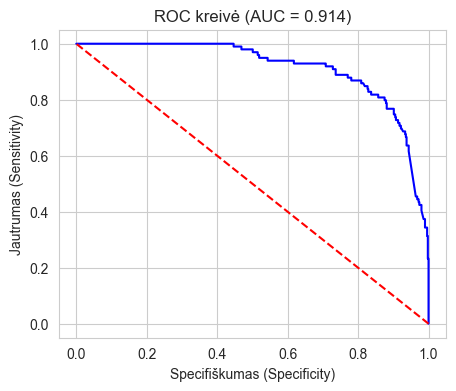

In [89]:
confusion_test(cloglog_model_original_multi, train_data)
ROC_plot(cloglog_model_original_multi, test_data)
plt.show()

### Cloglog modelis Youden

Optimalus slenkstis pagal Youdeno indeksą: 0.1888
Jautrumas  (Sensitivity): 0.9013
Specifiškumas (Specificity): 0.8486

Konfuzijos matrica:
         Prog. 0  Prog. 1
Tikra 0      431       66
Tikra 1       14       85

Procentais:
         Prog. 0  Prog. 1
Tikra 0     0.87     0.13
Tikra 1     0.14     0.86


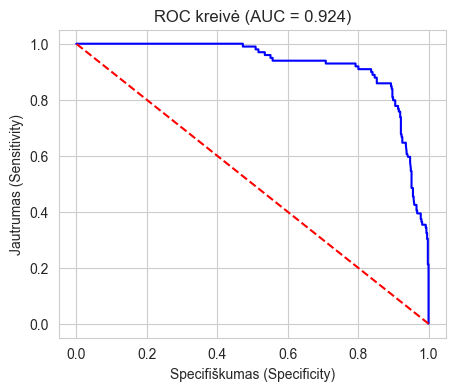

np.float64(0.18883200635863173)

In [90]:
ROC_youden_plot(cloglog_model_original_freq_of_use, train_data, test_data)

Optimalus slenkstis pagal Youdeno indeksą: 0.1496
Jautrumas  (Sensitivity): 0.9063
Specifiškumas (Specificity): 0.7611

Konfuzijos matrica:
         Prog. 0  Prog. 1
Tikra 0      378      119
Tikra 1       11       88

Procentais:
         Prog. 0  Prog. 1
Tikra 0     0.76     0.24
Tikra 1     0.11     0.89


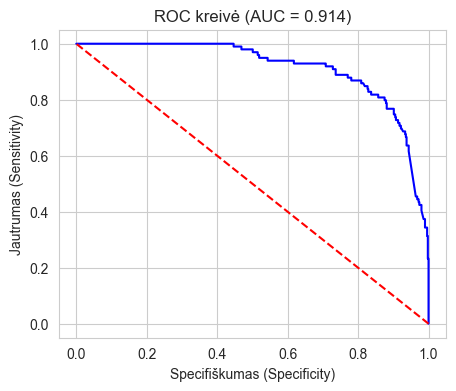

np.float64(0.14960367169963262)

In [91]:
ROC_youden_plot(cloglog_model_original_multi, train_data, test_data)